# 2D Computer Vision - Übung 2
## Histogrammanpassung

In [4]:
import numpy as np
from skimage import io
import matplotlib.pyplot as plt

### Hilfsfunktionen aus Übung 1

In [ ]:
def rgb_to_gray(image):
    return (0.299 * image[:, :, 0] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 2]).astype(np.uint8)


def computeHisto(image):
    if len(image.shape) == 3:
        image = rgb_to_gray(image)
    histo = np.zeros(256, dtype=int)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            histo[image[y, x]] += 1
    return histo


def apply_lut(image, lut):
    result = np.empty_like(image)
    if len(image.shape) == 3:
        for y in range(image.shape[0]):
            for x in range(image.shape[1]):
                for z in range(image.shape[2]):
                    result[y, x, z] = lut[image[y, x, z]]
    else:
        for y in range(image.shape[0]):
            for x in range(image.shape[1]):
                result[y, x] = lut[image[y, x]]
    return result

### Aufgabe 2 - compute_cumHisto

In [6]:
def compute_cumHisto(image, binSize=1):
    """
    Berechnet das kumulative Histogramm eines 8-Bit-Graustufenbildes.

    Parameters:
        image   : 8-Bit-Grauwertbild (2D) oder RGB-Bild (wird in Graustufen konvertiert)
        binSize : Breite jedes Bins (Standard=1 → 256 Bins)

    Returns:
        cumHisto: Kumulatives Histogramm als numpy-Array der Länge 256 // binSize
    """
    if len(image.shape) == 3:
        image = rgb_to_gray(image)

    num_bins = 256 // binSize
    histo = np.zeros(num_bins, dtype=int)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            bin_idx = image[y, x] // binSize
            histo[bin_idx] += 1

    cumHisto = np.cumsum(histo)
    return cumHisto

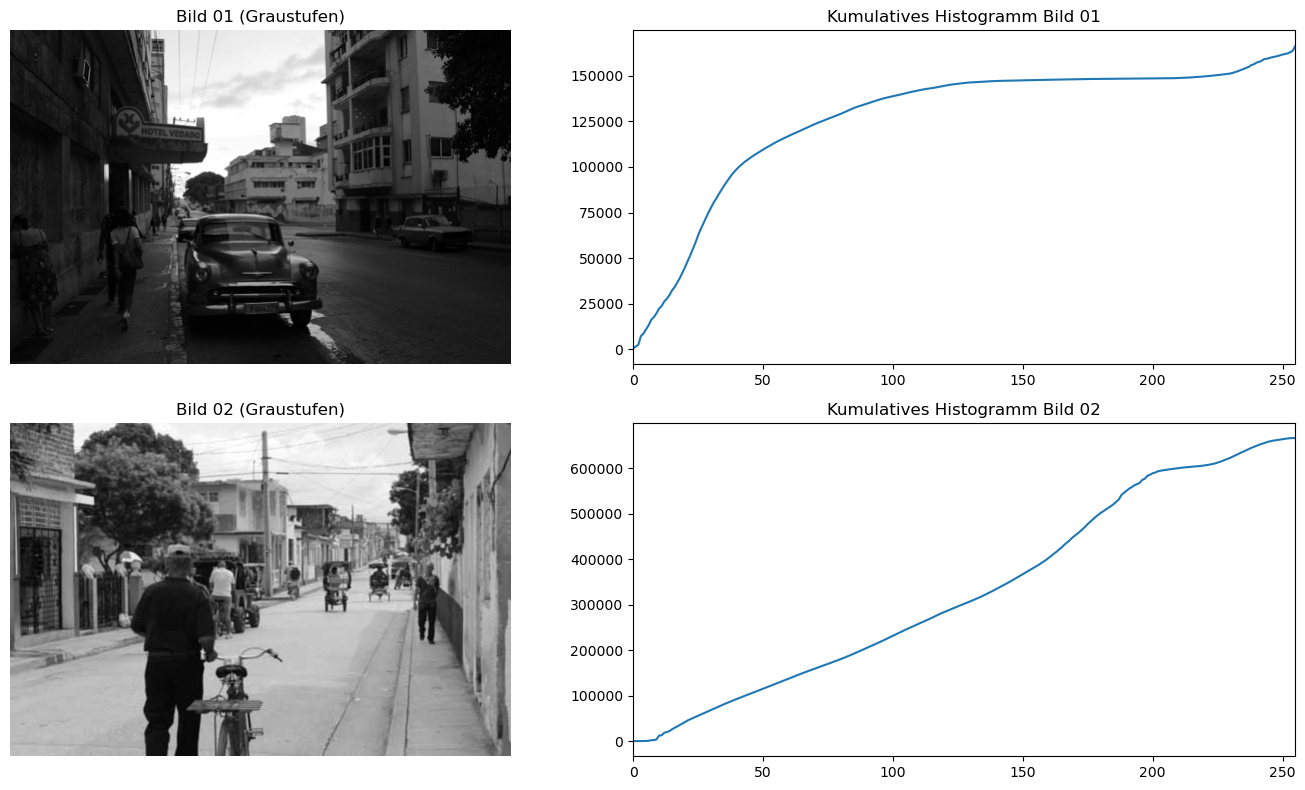

In [7]:
# Bilder einlesen und kumulatives Histogramm testen
img1 = io.imread("bild01.jpg")
img2 = io.imread("bild02.jpg")

gray1 = rgb_to_gray(img1)
gray2 = rgb_to_gray(img2)

cumH1 = compute_cumHisto(gray1, binSize=1)
cumH2 = compute_cumHisto(gray2, binSize=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(gray1, cmap="gray")
axes[0, 0].set_title("Bild 01 (Graustufen)")
axes[0, 0].axis("off")

axes[0, 1].plot(range(256), cumH1)
axes[0, 1].set_title("Kumulatives Histogramm Bild 01")
axes[0, 1].set_xlim([0, 255])

axes[1, 0].imshow(gray2, cmap="gray")
axes[1, 0].set_title("Bild 02 (Graustufen)")
axes[1, 0].axis("off")

axes[1, 1].plot(range(256), cumH2)
axes[1, 1].set_title("Kumulatives Histogramm Bild 02")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

### Aufgabe 3 - Theoretische Fragen

**a) Homogene vs. nicht-homogene Punktoperation:**

- **Homogene Punktoperation:** Das Ergebnis eines Ausgabepixels hängt ausschließlich vom Grauwert des entsprechenden Eingabepixels ab — unabhängig von dessen Position im Bild. Dieselbe Transformation wird auf jeden Pixel gleich angewendet.

- **Nicht-homogene Punktoperation:** Das Ergebnis hängt sowohl vom Grauwert als auch von der Position des Pixels ab. Verschiedene Bildbereiche werden unterschiedlich transformiert.

**b) Unterschied zwischen Punktoperationen und Filteroperationen:**

- **Punktoperation:** Jeder Ausgabepixel wird ausschließlich aus dem entsprechenden Eingabepixel berechnet. Es gibt keine Beziehung zu Nachbarpixeln. Die Operation ist lokal auf einen einzigen Punkt beschränkt.

- **Filteroperation:** Jeder Ausgabepixel wird aus einer ganzen Nachbarschaft von Eingabepixeln berechnet. Die räumliche Beziehung zwischen Pixeln spielt eine Rolle.

### Aufgabe 4 - Histogrammanpassung (match_Histo)

In [ ]:
def match_Histo(img_histo, ref_histo):
    # Histogramme normieren (→ Wahrscheinlichkeitsverteilung, unabhängig von Bildgröße)
    img_norm = img_histo / img_histo.sum()
    ref_norm = ref_histo / ref_histo.sum()

    # Kumulative Histogramme (CDF)
    img_cdf = np.cumsum(img_norm)
    ref_cdf = np.cumsum(ref_norm)

    # LUT aufbauen: für jeden Intensitätswert i den Wert j finden,
    # bei dem ref_cdf[j] am nächsten an img_cdf[i] liegt
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        diff = np.abs(ref_cdf - img_cdf[i])
        lut[i] = np.argmin(diff) 

    return lut

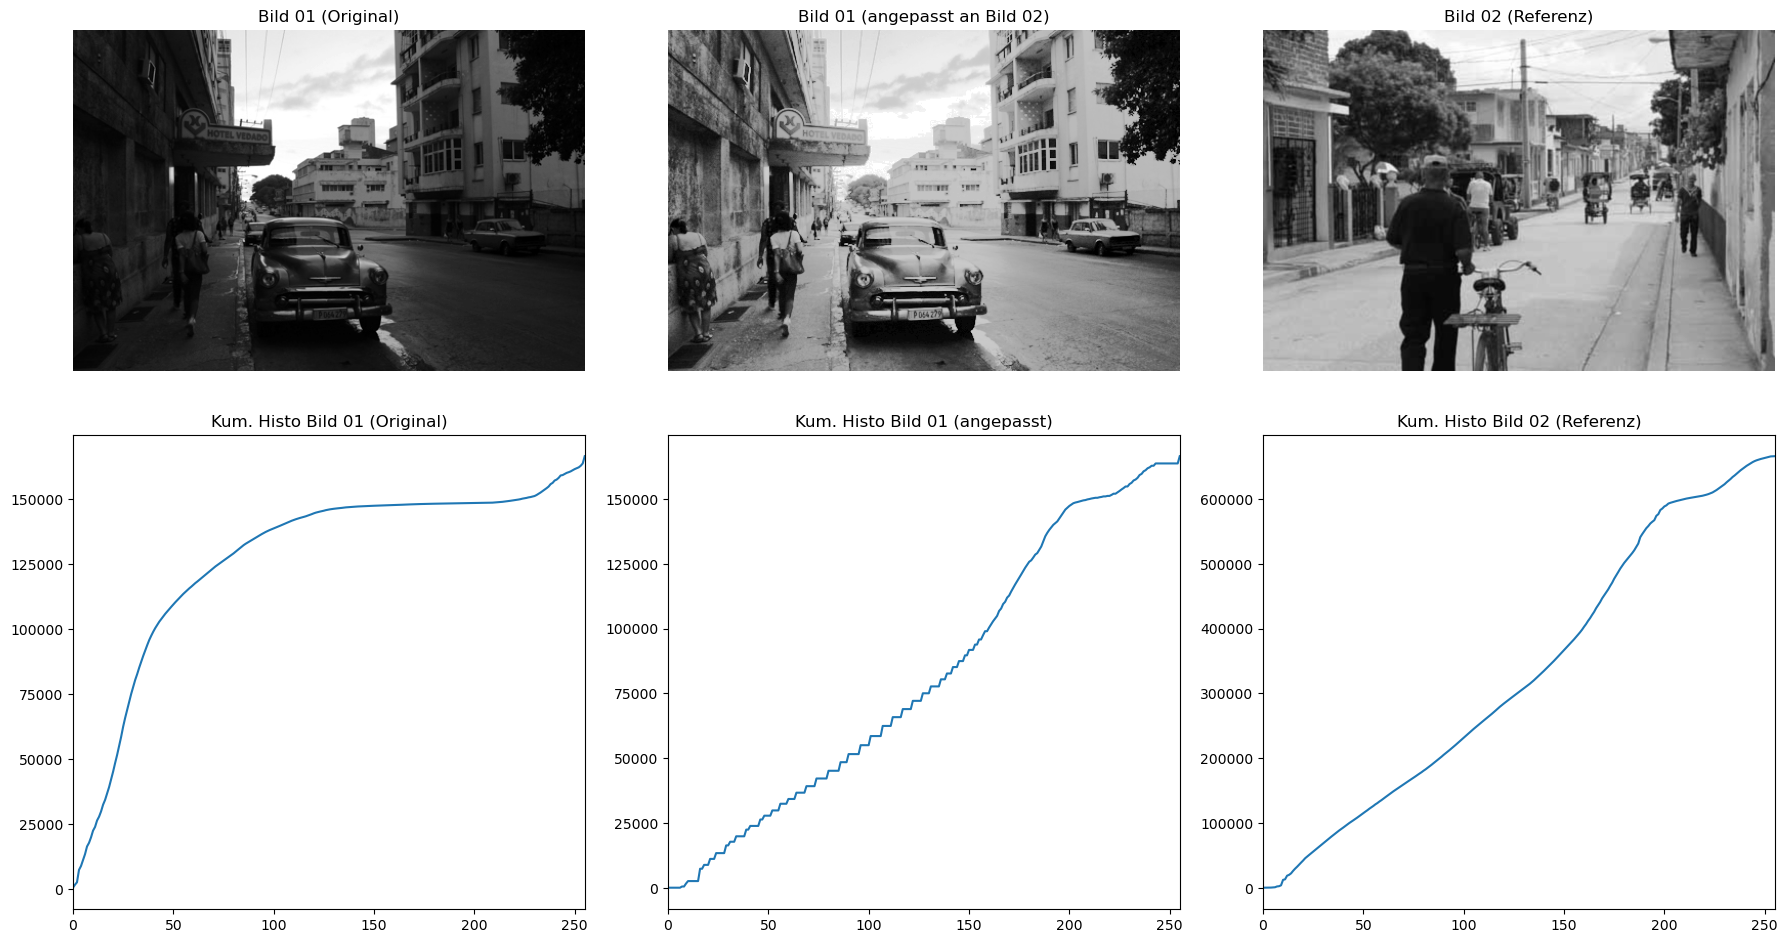

In [9]:
# Histogramme berechnen
histo1 = computeHisto(gray1)
histo2 = computeHisto(gray2)

# LUT berechnen: Bild01 an Bild02 anpassen
lut = match_Histo(histo1, histo2)

# LUT auf Bild01 anwenden
gray1_matched = apply_lut(gray1, lut)

# Kumulative Histogramme nach Anpassung
cumH1_matched = compute_cumHisto(gray1_matched, binSize=1)

# Visualisierung
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Bilder
axes[0, 0].imshow(gray1, cmap="gray")
axes[0, 0].set_title("Bild 01 (Original)")
axes[0, 0].axis("off")

axes[0, 1].imshow(gray1_matched, cmap="gray")
axes[0, 1].set_title("Bild 01 (angepasst an Bild 02)")
axes[0, 1].axis("off")

axes[0, 2].imshow(gray2, cmap="gray")
axes[0, 2].set_title("Bild 02 (Referenz)")
axes[0, 2].axis("off")

# Kumulative Histogramme
axes[1, 0].plot(range(256), cumH1)
axes[1, 0].set_title("Kum. Histo Bild 01 (Original)")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].plot(range(256), cumH1_matched)
axes[1, 1].set_title("Kum. Histo Bild 01 (angepasst)")
axes[1, 1].set_xlim([0, 255])

axes[1, 2].plot(range(256), cumH2)
axes[1, 2].set_title("Kum. Histo Bild 02 (Referenz)")
axes[1, 2].set_xlim([0, 255])

plt.tight_layout()
plt.show()